# Week 9 Phase 1.18A — acquisition compatibility and PA-TVR falsification

This notebook reads frozen artifacts. It does not generate an acquisition trajectory.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image, Markdown
ROOT=Path.cwd().parents[1] if Path.cwd().name=='week_09' else Path.cwd()
OUT=ROOT/'outputs'/'week9_phase1_18a_level_set_acquisition_compatibility_audit'
display(json.loads((OUT/'baseline_gate.json').read_text()))

{'budgets': [16, 24, 32, 40, 60, 80],
 'conduction': 332,
 'current_head': '2acdb9aba6bbadcd90ba0760ea0958c08e0ea593',
 'exact_branch_base': '2acdb9aba6bbadcd90ba0760ea0958c08e0ea593',
 'folds': 5,
 'historical_changes': [],
 'initial_design_matches': 100,
 'keyholes': 73,
 'outer_runs': 100,
 'paths': 100,
 'phase14_decision': 'LATE_ACQUISITION_GAIN_ONLY',
 'population': 405,
 'repeat_blocks': 20,
 'required_parent_sha': '2acdb9aba6bbadcd90ba0760ea0958c08e0ea593',
 'status': 'PASS'}

## M3 and the terminology correction

M3 is a frozen physics latent mean plus an ARD Matérn-3/2 discrepancy GPC. Probability margin is not variance-blind because predictive probability integrates latent uncertainty; it does not separately reward epistemic variance or global expected uncertainty reduction.

In [2]:
display(Markdown((OUT/'acquisition_definitions.md').read_text()))

# Acquisition definitions

- **M3_MARGIN:** `1-2|p_M3-0.5|`; point-local. `p_M3` integrates latent Gaussian variance, so this is not variance-blind. It does not separately reward epistemic variance or global expected reduction.
- **M3_STRADDLE:** `1.96 sigma_f-|mu_f|`; point-local latent-Gaussian adaptation of the canonical experimental Gotovos score. The 1.96 value is fixed, not outcome-tuned; Laplace classification does not inherit the original Gaussian-noise theory.
- **M3_EMI:** `sigma phi(|mu|/sigma)-|mu|Phi(-|mu|/sigma)`; point-local expected latent incorrectness relative to zero.
- **M3_SMOCU_APPROX:** expected finite-pool reduction of `k^-1 log(exp(kp)+exp(k(1-p)))`, `k=10`, using a disclosed logistic-Laplace rank-one moment update.
- **M3_SUR_APPROX:** expected finite-pool reduction in mean `p(1-p)` under the same update.
- **M3_TMES_GSUR:** local posterior variance reduction multiplied by latent contour-density weight `phi(mu/sigma)/sigma`.
- **PA_TVR_CANDIDATE:** local variance-reduction proxy times the supplied physics-gradient gate. It is neither a demonstrated tangent integral nor a global look-ahead.

All scores are maximized. Exact and approximate labels are retained in names and reports.


## Frozen-prefix score audit

In [3]:
scores=pd.read_csv(OUT/'candidate_scores_pre_reveal.csv.gz')
print(f'{len(scores):,} candidate occurrences; {scores[["run_id","budget"]].drop_duplicates().shape[0]} snapshots')
display(pd.read_csv(OUT/'margin_collapse_decisions.csv'))

169,200 candidate occurrences; 600 snapshots


,method,median_spearman,q05_spearman,top1_agreement,mean_top10_jaccard,decision
0,M3_STRADDLE,0.999111,0.471011,0.663333,0.844282,RANKING_DISTINCT_FROM_MARGIN
1,M3_EMI,0.987216,0.361368,0.660000,0.747583,RANKING_DISTINCT_FROM_MARGIN
2,M3_SMOCU_APPROX,-0.088419,-0.901432,0.351667,0.331473,RANKING_DISTINCT_FROM_MARGIN
3,M3_SUR_APPROX,0.688368,-0.770723,0.285000,0.437481,RANKING_DISTINCT_FROM_MARGIN
4,M3_TMES_GSUR,0.988436,0.361368,0.503333,0.699203,RANKING_DISTINCT_FROM_MARGIN
5,PA_TVR_CANDIDATE,0.977238,0.147313,0.221667,0.484480,RANKING_DISTINCT_FROM_MARGIN


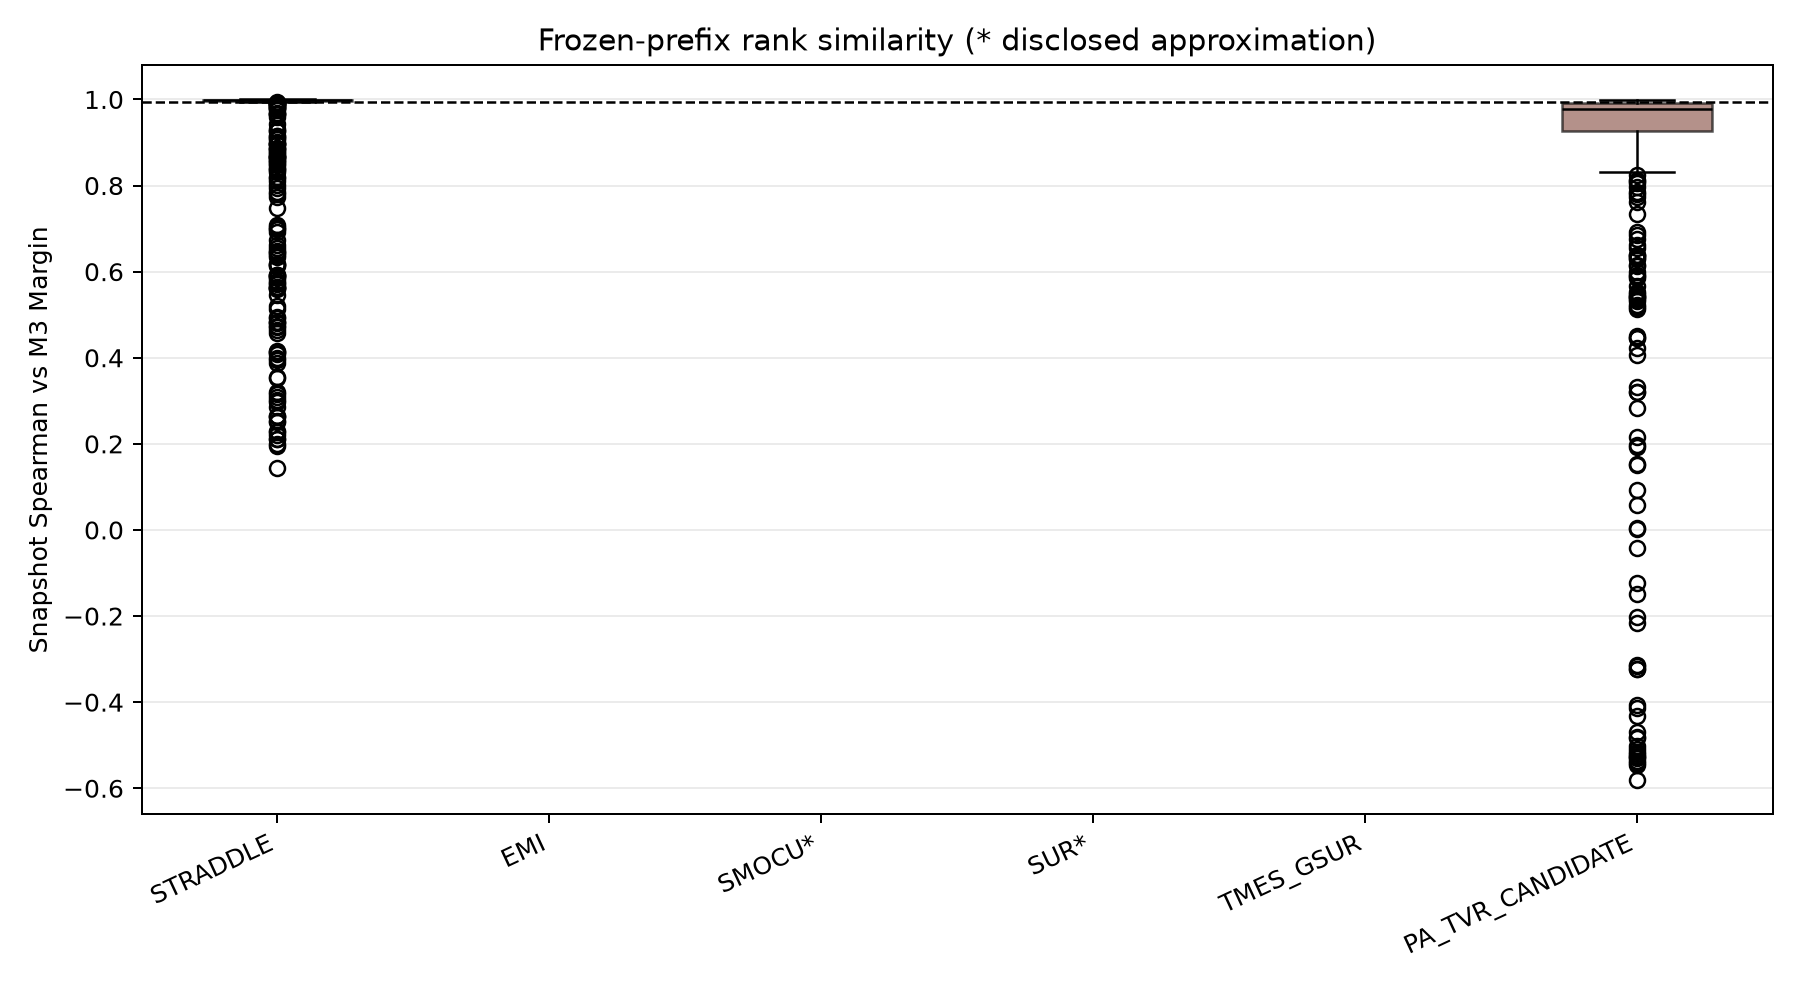

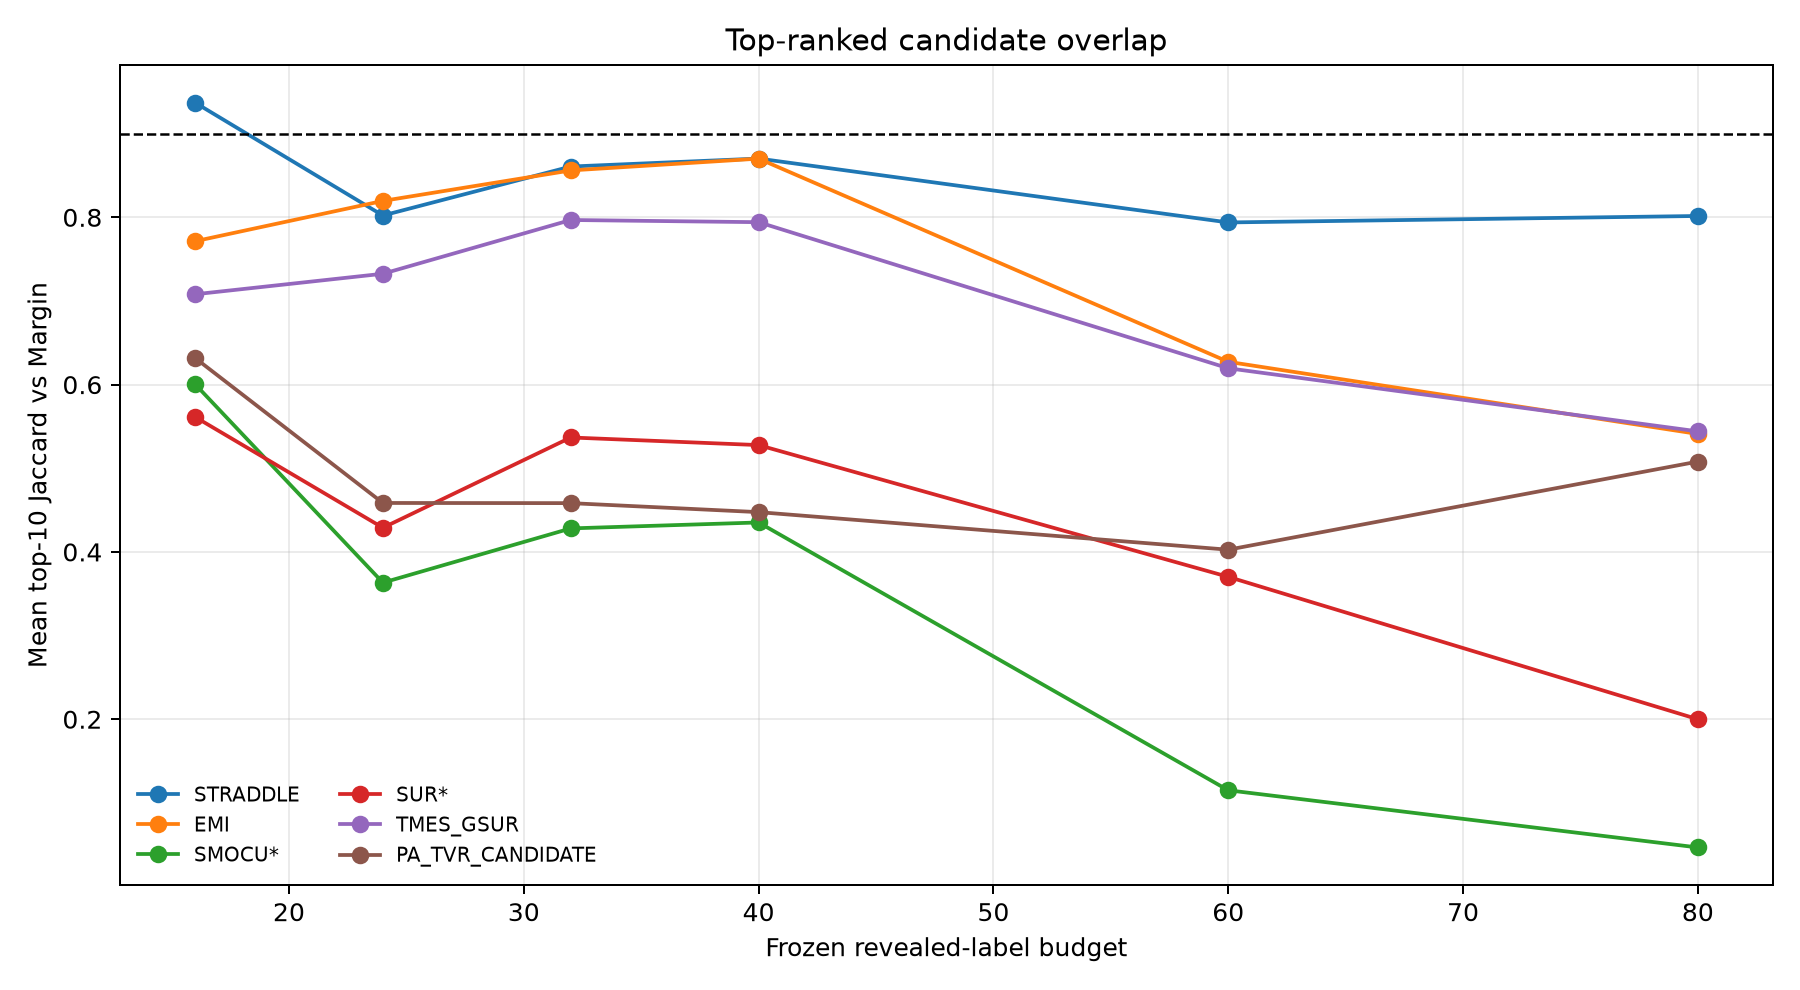

In [4]:
display(Image(filename=str(OUT/'figures'/'01_rank_correlation_vs_margin.png'))); display(Image(filename=str(OUT/'figures'/'02_top10_overlap_by_budget.png')))

## SMOCU and SUR

These are principled global one-step objectives. The full audit uses a disclosed logistic-Laplace rank-one moment approximation, so the artifacts never call them exact.

In [5]:
display(pd.read_csv(OUT/'method_decisions.csv'))

,method,decision,scope,reason
0,M3_MARGIN,COMPATIBLE_MARGIN_EQUIVALENT,point-local,reference local probability-margin rule
1,M3_STRADDLE,COMPATIBLE_DISTINCT,point-local,valid latent-local criterion; no GPC look-ahea...
2,M3_EMI,COMPATIBLE_DISTINCT,point-local,valid latent-local criterion; no GPC look-ahea...
3,M3_SMOCU_APPROX,REQUIRES_APPROXIMATION,one-step-look-ahead approximate,principled global one-step objective; current ...
4,M3_SUR_APPROX,REQUIRES_APPROXIMATION,one-step-look-ahead approximate,principled global one-step objective; current ...
5,M3_TMES_GSUR,COMPATIBLE_DISTINCT,geometry-local,local targeted variance-reduction proxy
6,PA_TVR_CANDIDATE,NOT_COMPATIBLE,geometry-local,supplied Matérn/tangent geometry factor lacks ...


## PA-TVR falsification

# PA-TVR derivation audit

The first factor is a defensible *local* Laplace rank-one variance-reduction approximation: adding site precision `W` at the same location changes variance by `v^2 W/(1+vW)`. `W_B` is the curvature at a plug-in posterior mean; `W_C` is more coherent before observing a label because it averages site curvature under the current latent posterior. `W_A` is predictive-label variance and is not the Laplace Hessian.

The second factor fails the audit. No integral over a tangent hyperplane was identified that yields `S^-1/2 exp(-2mu^2/S)` for an ARD MatÃ©rn-3/2 posterior. It resembles a Gaussian/RBF density gate under additional local-linear assumptions, but those assumptions neither match M3 nor account for cross-covariance to other points. Consequently the object is a physics-gradient-scaled local contour-density weighting, not demonstrated tangent variance reduction and not non-myopic SUR.


{'classification': 'physics-gradient-scaled local variance-reduction proxy',
 'decision': 'PA_TVR_REJECTED',
 'global_or_nonmyopic': False,
 'mathematics': 'geometry factor lacks a Matérn-3/2 tangent-integral derivation',
 'mean_top10_jaccard': 0.9656814944314944,
 'mean_top1_agreement': 0.9633333333333334,
 'median_L100_L1000_spearman': 0.9999986956153109,
 'numerically_fragile_L100_L1000': False,
 'prospective_recommendation': 'FAST_GPC_SUR',
 'recommendation_caveat': 'direct level-set/random-set prior art; implement and validate a literature-faithful classifier update before a single prospective trajectory',
 'truly_tangent': False}

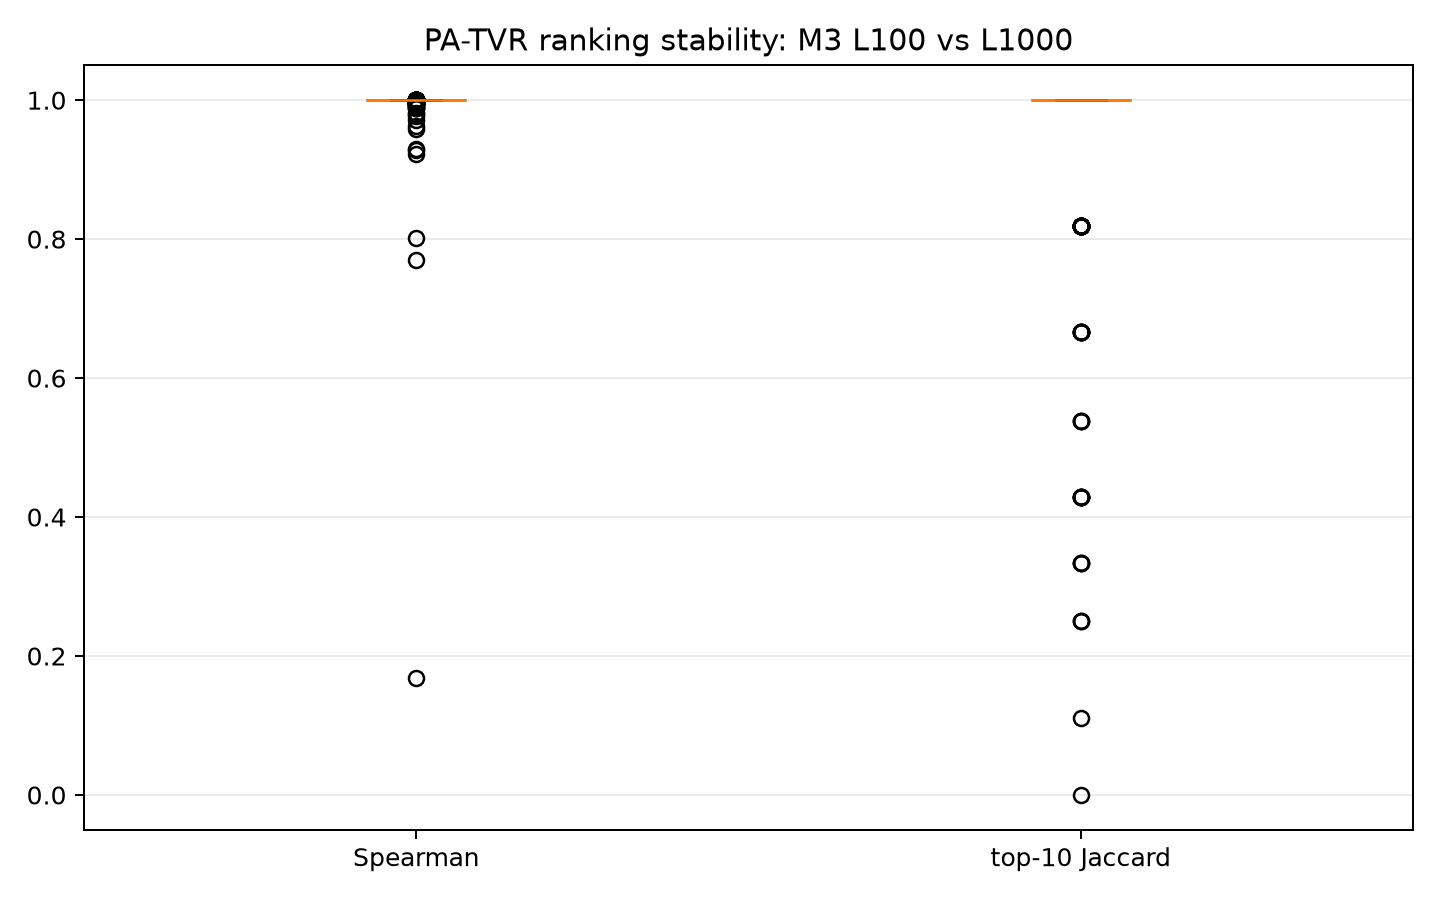

In [6]:
display(Markdown((OUT/'pa_tvr_derivation_audit.md').read_text())); display(json.loads((OUT/'pa_tvr_decision.json').read_text())); display(Image(filename=str(OUT/'figures'/'05_pa_tvr_bound_sensitivity.png')))

## Retrospective annotations are not performance

Truth and B1-like flags were joined only after the score table was frozen and hashed.

In [7]:
display(pd.read_csv(OUT/'retrospective_candidate_diagnostics.csv').head(14))

,method,budget,top_candidate_occurrences,keyhole_fraction_posthoc,q20_concentration_posthoc,q30_concentration_posthoc,median_B1_distance_posthoc,median_nearest_revealed_distance,median_P,median_VX,median_LS,median_ST,median_h
0,M3_EMI,16,100,0.48,0.67,0.79,0.771430,1.235459,243.489580,0.426691,0.000053,351.677261,9.259385e+08
1,M3_EMI,24,100,0.43,0.79,0.85,0.776961,1.093409,220.648566,0.437256,0.000053,340.774386,8.898793e+08
2,M3_EMI,32,100,0.41,0.75,0.93,0.773559,0.871554,243.936893,0.527189,0.000053,330.289975,8.805183e+08
3,M3_EMI,40,100,0.47,0.75,0.90,0.791413,0.790395,277.934087,0.472528,0.000057,330.289975,8.320187e+08
4,M3_EMI,60,100,0.40,0.54,0.66,0.842897,0.769051,353.971839,0.898098,0.000045,374.882576,1.343660e+09
5,M3_EMI,80,100,0.34,0.34,0.58,1.023240,0.711311,245.085542,0.781444,0.000046,375.783913,6.625447e+08
6,M3_MARGIN,16,100,0.51,0.68,0.81,0.771430,1.224624,245.117557,0.393164,0.000053,351.677261,9.409866e+08
7,M3_MARGIN,24,100,0.51,0.84,0.88,0.770156,0.933504,224.336324,0.300981,0.000050,349.246856,9.207685e+08
8,M3_MARGIN,32,100,0.39,0.79,0.93,0.764769,0.794494,243.936893,0.471971,0.000053,338.445130,8.843744e+08
9,M3_MARGIN,40,100,0.47,0.76,0.90,0.791413,0.770701,243.042266,0.437256,0.000055,332.067560,8.320187e+08


## Safe conclusion

In [8]:
display(Markdown((OUT/'SUPERVISOR_PHASE1_18A_ONE_PAGE.md').read_text()))

# Supervisor Phase 1.18A â€” one page

- **Design:** 600 frozen M3 snapshots, 169,200 candidate occurrences, no new acquisition path.
- **Margin correction:** it integrates latent uncertainty through `p_M3`; it simply lacks an explicit global expected-reduction objective.
- **Local criteria:** Straddle vs Margin median Spearman 0.9991, top-1 66.3%; EMI 0.9872, top-1 66.0%.
- **Global candidates:** SMOCU/SUR were scored with an explicit logistic-Laplace rank-one approximation and remain approximation-requiring, not exact results.
- **PA-TVR:** the local variance update is defensible, but the claimed tangent MatÃ©rn geometry and global interpretation are not. L100/L1000 median Spearman 1.0000.
- **Decision:** **PA_TVR_REJECTED**. Do not repair it ad hoc.
- **One possible next experiment:** FAST_GPC_SUR, only after a faithful GPC-SUR update validation gate. No q20 optimization or sample-efficiency claim was performed here.
